<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## RNN many-to-one

#### Datos
El objecto es utilizar una serie de sucuencias númericas (datos sintéticos) para poner a prueba el uso de las redes RNN. Este ejemplo se inspiró en otro artículo, lo tienen como referencia en el siguiente link:\
[LINK](https://stackabuse.com/solving-sequence-problems-with-lstm-in-keras/)

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
# Generar datos sintéticos
X = list()
y = list()

# X será una lista de 1 a 45 agrupado de a 3 números consecutivos
# [ [1, 2, 3], [4, 5, 6], ....]
X = [[x, x + 1, x + 2] for x in range(1, 46, 3)]

# "y" (target) se obtiene como la suma de cada grupo de 3 números de entrada
y = [sum(x) for x in X]

X = np.array(X).reshape(len(X), 3, 1)  # (n_samples, seq_len, n_features)
y = np.array(y).reshape(-1, 1)

print("datos X:", X)
print("datos y:", y)

datos X: [[[ 1]
  [ 2]
  [ 3]]

 [[ 4]
  [ 5]
  [ 6]]

 [[ 7]
  [ 8]
  [ 9]]

 [[10]
  [11]
  [12]]

 [[13]
  [14]
  [15]]

 [[16]
  [17]
  [18]]

 [[19]
  [20]
  [21]]

 [[22]
  [23]
  [24]]

 [[25]
  [26]
  [27]]

 [[28]
  [29]
  [30]]

 [[31]
  [32]
  [33]]

 [[34]
  [35]
  [36]]

 [[37]
  [38]
  [39]]

 [[40]
  [41]
  [42]]

 [[43]
  [44]
  [45]]]
datos y: [[  6]
 [ 15]
 [ 24]
 [ 33]
 [ 42]
 [ 51]
 [ 60]
 [ 69]
 [ 78]
 [ 87]
 [ 96]
 [105]
 [114]
 [123]
 [132]]


In [3]:
# Train/valid split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Los pasamos a tensores para poder meterlos a la RRN
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)

In [4]:
y = np.asanyarray(y)
y.shape

(15, 1)

### 2 - Entrenar el modelo

In [5]:
input_shape = X[0].shape
input_shape

(3, 1)

In [6]:
output_shape = 1
output_shape

1

In [7]:
class RNN(nn.Module):
    def __init__(
        self, input_size=1, hidden_size=64, output_size=1, bidirectional=False
    ):
        super(RNN, self).__init__()
        self.rnn = nn.RNN(
            input_size, hidden_size, batch_first=True, bidirectional=bidirectional
        )
        self.fc = nn.Linear(hidden_size * (2 if bidirectional else 1), output_size)
        self.relu = nn.ReLU()

    def forward(self, x):
        out, _ = self.rnn(x)
        out = out[:, -1, :]  # última salida de la secuencia
        out = self.relu(out)
        out = self.fc(out)
        return out

In [ ]:
def train_model(
    model,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=5000,
    batch_size=5,
    lr=0.001,
    patience=60,
    min_delta=1e-4,
):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "val_loss": []}

    n_samples = X_train.shape[0]
    # best_val_loss = float("inf")
    # patience_counter = 0
    # best_model_state = None

    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(n_samples)
        batch_losses = []

        for i in range(0, n_samples, batch_size):
            idx = perm[i : i + batch_size]
            xb, yb = X_train[idx], y_train[idx]

            optimizer.zero_grad()
            outputs = model(xb)
            loss = criterion(outputs, yb)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())

        # Validación
        model.eval()
        with torch.no_grad():
            val_pred = model(X_val)
            val_loss = criterion(val_pred, y_val).item()

        train_loss_mean = np.mean(batch_losses)
        history["train_loss"].append(train_loss_mean)
        history["val_loss"].append(val_loss)

        if (epoch + 1) % 50 == 0:
            print(
                f"Epoch [{epoch + 1}/{epochs}], Train Loss: {train_loss_mean:.4f}, Val Loss: {val_loss:.4f}"
            )

    return history

In [11]:
model1 = RNN()
hist1 = train_model(model1, X_train, y_train, X_val, y_val, epochs=2000)

Epoch [50/2000], Train Loss: 6926.8466, Val Loss: 5563.7896
Epoch [100/2000], Train Loss: 5674.1603, Val Loss: 5140.2168
Epoch [150/2000], Train Loss: 4231.9387, Val Loss: 4752.2944
Epoch [200/2000], Train Loss: 3578.7911, Val Loss: 4406.6045
Epoch [250/2000], Train Loss: 3483.6360, Val Loss: 4091.1492
Epoch [300/2000], Train Loss: 3216.4041, Val Loss: 3809.0154
Epoch [350/2000], Train Loss: 2772.1536, Val Loss: 3552.1045
Epoch [400/2000], Train Loss: 3563.0068, Val Loss: 3211.9941
Epoch [450/2000], Train Loss: 2781.3718, Val Loss: 2928.4924
Epoch [500/2000], Train Loss: 2849.0953, Val Loss: 2674.9136
Epoch [550/2000], Train Loss: 2758.0627, Val Loss: 2444.3274
Epoch [600/2000], Train Loss: 2868.8641, Val Loss: 2231.6750
Epoch [650/2000], Train Loss: 1850.4919, Val Loss: 2035.2032
Epoch [700/2000], Train Loss: 1853.4935, Val Loss: 1854.0977
Epoch [750/2000], Train Loss: 1800.8980, Val Loss: 1686.3527
Epoch [800/2000], Train Loss: 1808.3201, Val Loss: 1531.6123
Epoch [850/2000], Train L

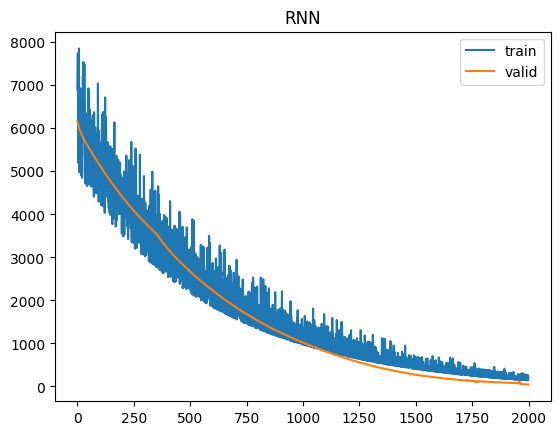

In [13]:
# Curva de entrenamiento
plt.plot(hist1["train_loss"], label="train")
plt.plot(hist1["val_loss"], label="valid")
plt.legend()
plt.title("RNN")
plt.show()

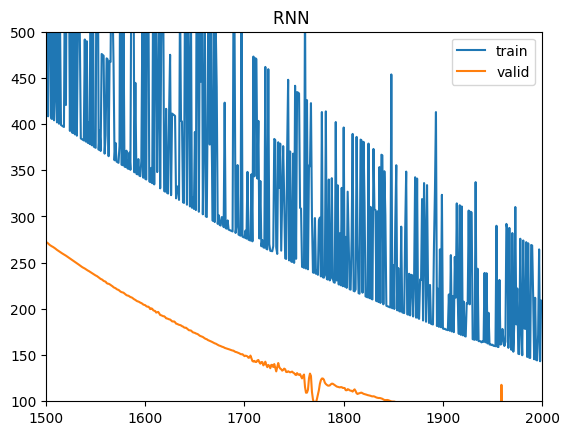

In [14]:
# Curva de entrenamiento
plt.plot(hist1["train_loss"], label="train")
plt.plot(hist1["val_loss"], label="valid")
plt.ylim(100, 500)
plt.xlim(1500, 2000)
plt.legend()
plt.title("RNN ")
plt.show()

In [15]:
# Ensayo
x_test = np.array([[50, 51, 52]]).reshape((1, 3, 1))
x_test = torch.tensor(x_test, dtype=torch.float32)
y_test = torch.tensor([[sum([50, 51, 52])]], dtype=torch.float32)

with torch.no_grad():
    y_hat1 = model1(x_test).item()

print("Modelo Simple y_test:", y_test.item(), "y_hat:", y_hat1)

Modelo Simple y_test: 153.0 y_hat: 97.32609558105469


### 3 - Bidirectional RNN (BRNN)

In [16]:
# En esta oportunidad se utilizará Bidirectional, dentro se especifica
# que lo que se desea hacer bidireccional es una capa LSTM

# En el summary se puede observar que la cantidad de parámetros
# de nuestor nueva capa LSTM bidireccional es el doble que la anterior

model2 = RNN(bidirectional=True)

hist2 = train_model(model2, X_train, y_train, X_val, y_val, epochs=1800)

with torch.no_grad():
    y_hat2 = model2(x_test).item()

print("y_test:", y_test.item())
print("y_hat (bidirectional):", y_hat2)

Epoch [50/1800], Train Loss: 4764.2176, Val Loss: 4944.7891
Epoch [100/1800], Train Loss: 3421.9701, Val Loss: 4064.6990
Epoch [150/1800], Train Loss: 2957.5375, Val Loss: 3385.7214
Epoch [200/1800], Train Loss: 2252.5864, Val Loss: 2682.8347
Epoch [250/1800], Train Loss: 2986.9730, Val Loss: 2108.1755
Epoch [300/1800], Train Loss: 2028.4725, Val Loss: 1667.0366
Epoch [350/1800], Train Loss: 1182.8902, Val Loss: 1291.9379
Epoch [400/1800], Train Loss: 1023.1907, Val Loss: 1008.1757
Epoch [450/1800], Train Loss: 819.9237, Val Loss: 775.4119
Epoch [500/1800], Train Loss: 761.8719, Val Loss: 582.8500
Epoch [550/1800], Train Loss: 744.4639, Val Loss: 432.7291
Epoch [600/1800], Train Loss: 476.2029, Val Loss: 314.9742
Epoch [650/1800], Train Loss: 396.4262, Val Loss: 223.3104
Epoch [700/1800], Train Loss: 328.6139, Val Loss: 155.9311
Epoch [750/1800], Train Loss: 399.1634, Val Loss: 108.0026
Epoch [800/1800], Train Loss: 275.6133, Val Loss: 69.4771
Epoch [850/1800], Train Loss: 265.8555, Va

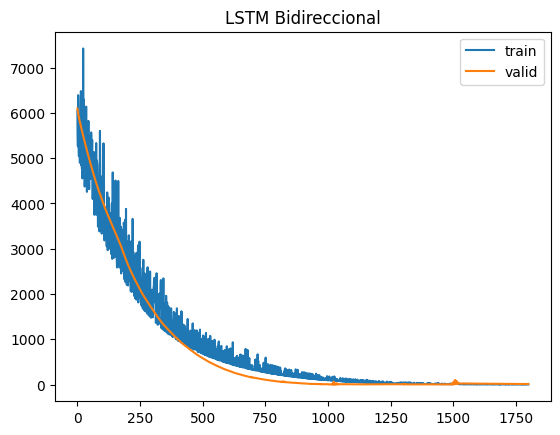

In [17]:
plt.plot(hist2["train_loss"], label="train")
plt.plot(hist2["val_loss"], label="valid")
plt.legend()
plt.title("LSTM Bidireccional")
plt.show()

In [18]:
# Ensayo
x_test = np.array([[50, 51, 52]]).reshape((1, 3, 1))
x_test = torch.tensor(x_test, dtype=torch.float32)
y_test = torch.tensor([[sum([50, 51, 52])]], dtype=torch.float32)

with torch.no_grad():
    y_hat2 = model2(x_test).item()

print("Modelo Bidireccional y_test:", y_test.item(), "y_hat:", y_hat2)

Modelo Bidireccional y_test: 153.0 y_hat: 126.61320495605469


### 4 - Conclusión
Implementar un modelo bidireccional basado en RNN es muy sencillo. Más allá de que esta tarea podria resolverse de otras maneras, les queda nota de como definir y entrenar estos tipos de redes neuronales recurrentes con y sin bidireccionalidad.